# MATH840 — Lab 3: Decomposing your series

**Week 3 | graded assignment 2 of 7 | 8 points | due at the end of the session**

You have a series, and in Lab 2 you found out which simple method wins on it. This week you
find out **why**: what is in the series, and which component that method was exploiting.

**Keep the section headings below.** They map one-to-one onto the marking rubric:

| Section | Criteria | Points |
|---|---|---|
| 1 | Data preparation — does the variance need stabilising? | 1 |
| 2 | EDA and visualisation — two decompositions, compared, and the adjusted series | 4 |
| 3 | Implementation — $F_T$, $F_S$ and last week's winner explained | 2 |
| 4 | Code quality and reproducibility | 1 |

Submit `SURNAME_lab03.pdf`, `SURNAME_lab03.ipynb` and `SURNAME_lab03_summary.csv` to Moodle
before the end of the session. A valid partial submission scores; a perfect missing one
does not.

## 0. Setup

Given — run it and move on. Nothing in this section is marked.

In [21]:
!pip install -q statsforecast utilsforecast coreforecast

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from coreforecast.scalers import boxcox, boxcox_lambda

pd.set_option("display.width", 120)
print("pandas", pd.__version__)

pandas 2.2.3


In [22]:
SURNAME = "Bondar"   # <-- for your submission file names
MY_ID   = "mbondar@kse.org.ua"   # <-- the SAME identifier you used in Weeks 1 and 2

if not SURNAME.strip() or not MY_ID.strip():
    raise ValueError("Set SURNAME and MY_ID before running the rest.")

The assignment function from Week 1, unchanged. The same identifier gives you the same
series — **do not switch datasets**: this lab explains the result Lab 2 produced on it.

In [23]:
BASE = ("https://raw.githubusercontent.com/Aranaur/aranaur.rbind.io/"
        "main/lectures/kse/MATH840/26autumn/data")

POOL = (
    [{"file": "aus_production.csv", "column": c, "freq": "QS", "season": 4,
      "label": f"Australian production: {c}"}
     for c in ["Beer", "Tobacco", "Bricks", "Cement", "Electricity", "Gas"]]
    + [{"file": "tourism.csv", "state": s, "purpose": p, "freq": "QS", "season": 4,
        "label": f"Tourism: {p} trips to {s}"}
       for s in ["South Australia", "Northern Territory", "Western Australia",
                 "Victoria", "New South Wales", "Queensland", "ACT", "Tasmania"]
       for p in ["Business", "Holiday", "Other", "Visiting"]]
    + [{"file": "ansett.csv", "route": r, "class": c, "freq": "W-MON", "season": 52,
        "label": f"Ansett passengers: {r}, {c} class"}
       for r in ["MEL-SYD", "MEL-ADL", "SYD-BNE", "MEL-BNE", "ADL-PER", "MEL-PER"]
       for c in ["Business", "Economy"]]
)


def assign_dataset(student_id: str) -> dict:
    digest = hashlib.sha256(student_id.strip().encode("utf-8")).hexdigest()
    return POOL[int(digest, 16) % len(POOL)]


def load_my_series(spec: dict) -> pd.DataFrame:
    df = pd.read_csv(f"{BASE}/{spec['file']}")
    if spec["file"] == "aus_production.csv":
        out = df[["ds", spec["column"]]].rename(columns={spec["column"]: "y"})
    elif spec["file"] == "tourism.csv":
        sub = df[(df["State"] == spec["state"]) & (df["Purpose"] == spec["purpose"])]
        out = sub.groupby("ds", as_index=False)["y"].sum()
    else:
        sub = df[(df["Airports"] == spec["route"]) & (df["Class"] == spec["class"])]
        out = sub[["ds", "y"]].copy()
    out["ds"] = pd.to_datetime(out["ds"])
    return out.sort_values("ds").reset_index(drop=True)


mine = assign_dataset(MY_ID)
raw = load_my_series(mine)
print(mine["label"], "|", mine["freq"], "| season length", mine["season"])

Ansett passengers: ADL-PER, Economy class | W-MON | season length 52


**Your series, prepared the way Lab 2 asked.** Loading and repairing the calendar were marked
last week, so they are not marked again. This cell averages duplicated timestamps, puts the
series on a regular calendar, trims a missing tail and interpolates interior gaps.

If you made different choices in Lab 2, replace this cell with your own Section 1 code — keep
using `mine["freq"]` for the calendar — and end with the same frame, `s`, with columns `ds`
and `y`.

In [24]:
s = raw.groupby("ds", as_index=False)["y"].mean() if raw["ds"].duplicated().any() else raw.copy()
grid = pd.date_range(s["ds"].min(), s["ds"].max(), freq=mine["freq"])
s = s.set_index("ds").reindex(grid).rename_axis("ds")
s["y"] = s["y"].interpolate(limit_area="inside")
s = s.dropna().reset_index()

print(f"{len(s)} observations, {s['ds'].min().date()} to {s['ds'].max().date()}, "
      f"{len(s) / mine['season']:.1f} seasonal cycles")
s.head()

283 observations, 1987-06-29 to 1992-11-23, 5.4 seasonal cycles


,ds,y
0,1987-06-29,2084.0
1,1987-07-06,2186.0
2,1987-07-13,2137.0
3,1987-07-20,2090.0
4,1987-07-27,1595.0


## 1. Data preparation

*1 point.* **Does the variance need stabilising?** Does the size of the seasonal swing grow
with the level of the series? If it does, an additive decomposition is the wrong model for it.

Estimate a Box-Cox $\lambda$, plot the transformed series next to the original, and then
**decide**. A defensible "no transformation needed" earns full marks; an unexplained
transformation does not.

```python
y = s["y"].to_numpy(float)
lam = boxcox_lambda(y, method="loglik", season_length=mine["season"])
y_transformed = boxcox(y, lam)
```

**If your series contains zeros:** `method="loglik"` refuses non-positive values,
`method="guerrero"` may return $\lambda = 0$ (the log transform, undefined at zero), and a
multiplicative decomposition refuses them too. That is information about your series, not an
obstacle — find out where the zeros come from, and say what you concluded.

📖 [`boxcox` / `boxcox_lambda`](https://nixtlaverse.nixtla.io/coreforecast/) ·
[`scipy.stats.boxcox`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html)
(an alternative that returns the transform and λ together) ·
[FPP 3.1 transformations](https://otexts.com/fpp3/transformations.html) ·
[FPP the Pythonic Way, ch. 3](https://otexts.com/fpppy/nbs/03-decomposition.html)

In [25]:
print("Minimum value:", s["y"].min())
print("Number of zero values:", (s["y"] == 0).sum())
print("Number of negative values:", (s["y"] < 0).sum())

s.loc[s["y"] <= 0, ["ds", "y"]]

Minimum value: 0.0
Number of zero values: 11
Number of negative values: 0


,ds,y
112,1989-08-21,0.0
113,1989-08-28,0.0
114,1989-09-04,0.0
115,1989-09-11,0.0
116,1989-09-18,0.0
117,1989-09-25,0.0
118,1989-10-02,0.0
119,1989-10-09,0.0
120,1989-10-16,0.0
125,1989-11-20,0.0


Estimated Box-Cox lambda = 2.000


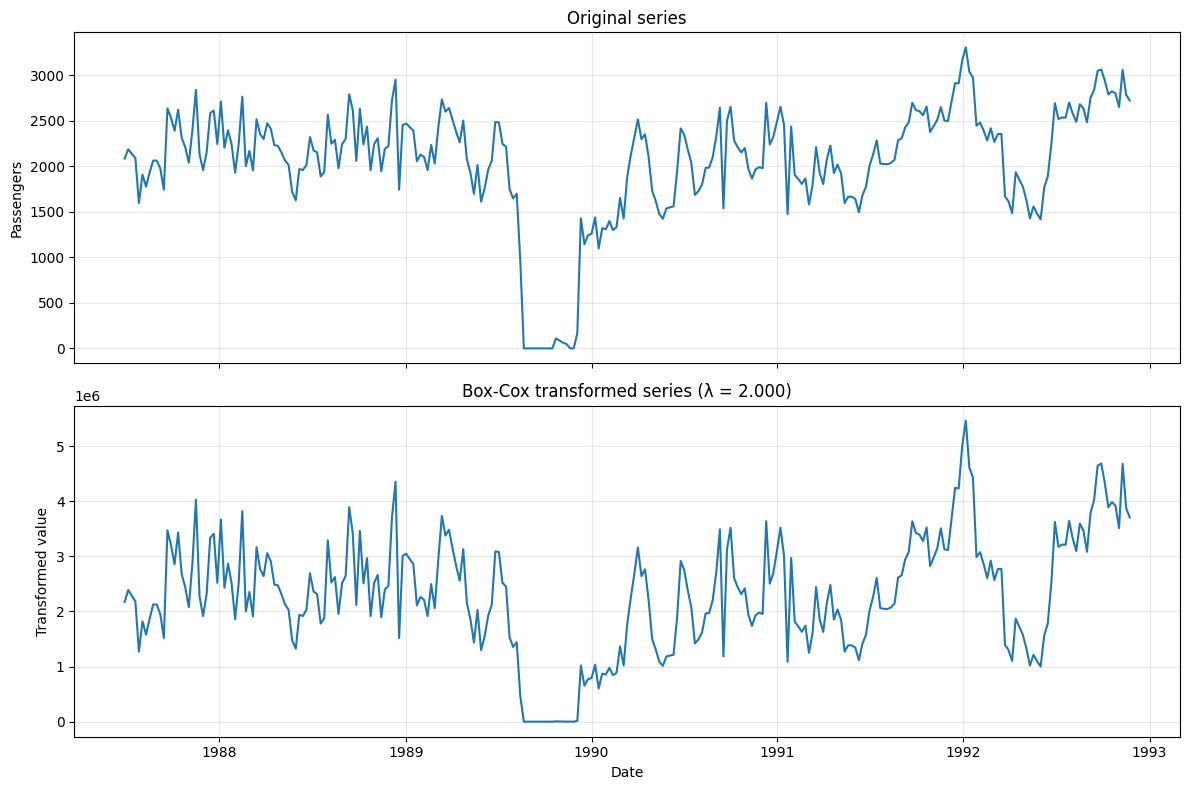

In [26]:
# TODO: estimate lambda, plot original vs transformed, decide.
# Set `work` to the version of the series you will decompose in Section 2.

y = s["y"].to_numpy(float)

lam = boxcox_lambda(
    y,
    method="guerrero",
    season_length=mine["season"]
)
print(f"Estimated Box-Cox lambda = {lam:.3f}")

y_transformed = boxcox(y, lam)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(s["ds"], y)
axes[0].set_title("Original series")
axes[0].set_ylabel("Passengers")
axes[0].grid(alpha=0.3)

axes[1].plot(s["ds"], y_transformed)
axes[1].set_title(f"Box-Cox transformed series (λ = {lam:.3f})")
axes[1].set_ylabel("Transformed value")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

work = s.copy()

**Your decision and why.**

→ The estimated Box-Cox lambda is 2.00. The series contains 11 zero values, all appearing in 1989, so the log-likelihood method cannot be used. The estimated lambda is at the maximum value of 2.00. After the transformation, the high values become more pronounced, and there is no clear evidence that the variance has become more stable. Therefore, I decided to keep the original series without transformation for the decomposition.

## 2. EDA and visualisation

*4 points — one per subsection.* All on `work`, the version you settled on in Section 1.
Every plot needs a reading; a plot with no reading attached earns nothing.

Reading the components means something a colleague could act on — not "the trend goes up",
but *the seasonal component is stable until 2008 and shifts afterwards*, *the remainder is
flat except for three spikes*, *the trend flattens in the last two years*.

**⚠️ Where this goes wrong.**
- `seasonal_decompose` returns `NaN` for the first and last `period / 2` observations. That is
  the centred moving average, not a bug — and one of the differences 2.3 asks about.
- `model="multiplicative"` refuses zeros and negative values.
- `STL(...)` needs `seasonal` to be an **odd** integer ≥ 3, and an `int`, not a float.
- Both need `period` — observations per cycle, `mine["season"]`, not the number of years.

📖 [`seasonal_decompose`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) ·
[`STL`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html) ·
[FPP 3.4 classical decomposition](https://otexts.com/fpp3/classical-decomposition.html) ·
[FPP 3.6 STL](https://otexts.com/fpp3/stl.html)

### 2.1 Classical decomposition

*1 point.* `seasonal_decompose`, plotted, and read.

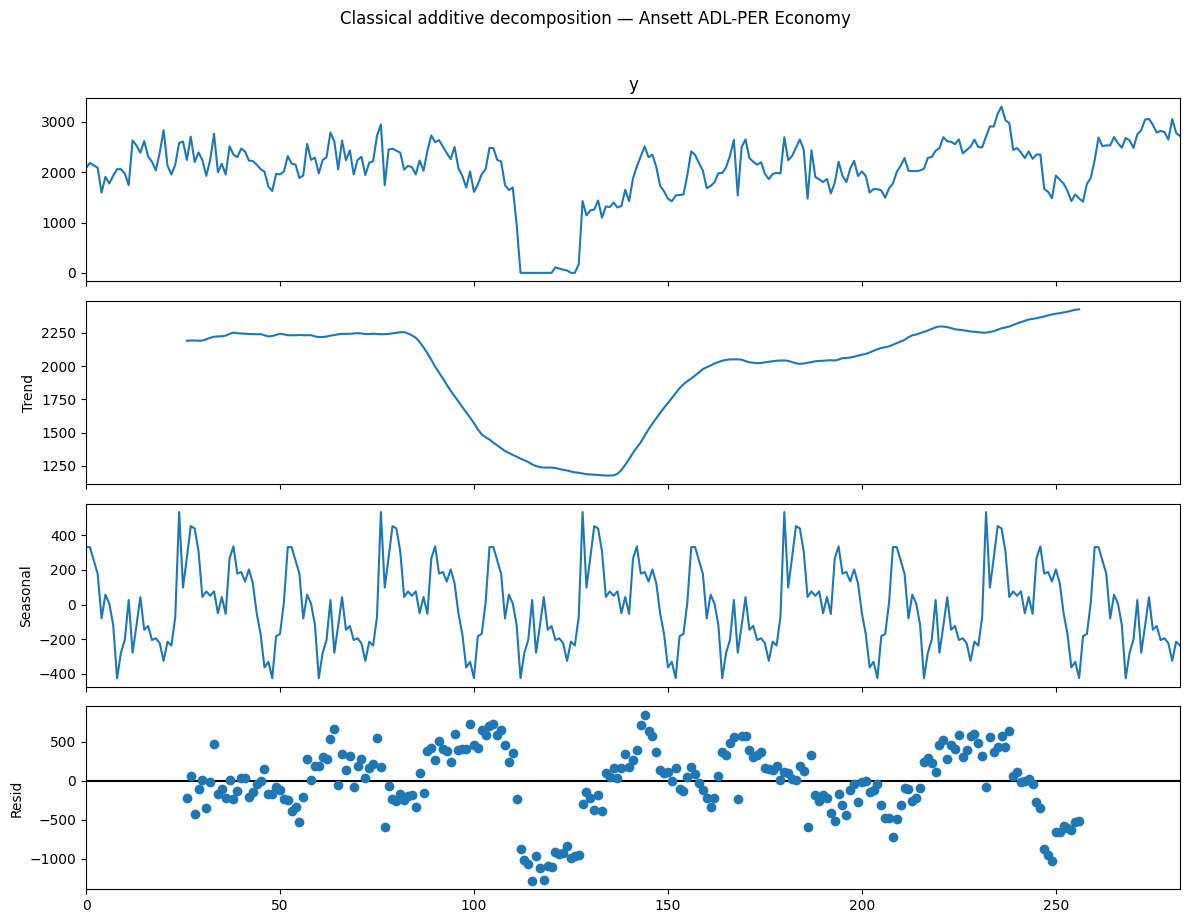

In [27]:
# TODO: classical decomposition

classical = seasonal_decompose(
    work["y"],
    model="additive",
    period=mine["season"]
)

fig = classical.plot()
fig.set_size_inches(12, 9)
fig.suptitle("Classical additive decomposition — Ansett ADL-PER Economy", y=1.02)
plt.tight_layout()
plt.show()

**Reading the classical components.**

→  The classical decomposition shows a fairly stable trend of around 2200 passengers per week until 1988. The trend then drops strongly during 1989. It starts increasing again in 1991–1992 and reaches about 2400 passengers near the end of the series. The seasonal component shows a clear repeating yearly pattern, with an amplitude of around 400 passengers. This suggests that passenger numbers have a regular yearly seasonal pattern. The residuals contain several long periods of positive and negative values. The large negative residuals during the 1989 disruption show that the classical decomposition does not fully explain this unusual event.

### 2.2 STL

*1 point.* `STL` with a stated choice of `seasonal` and `robust` — say why you chose them —
plotted, and read.

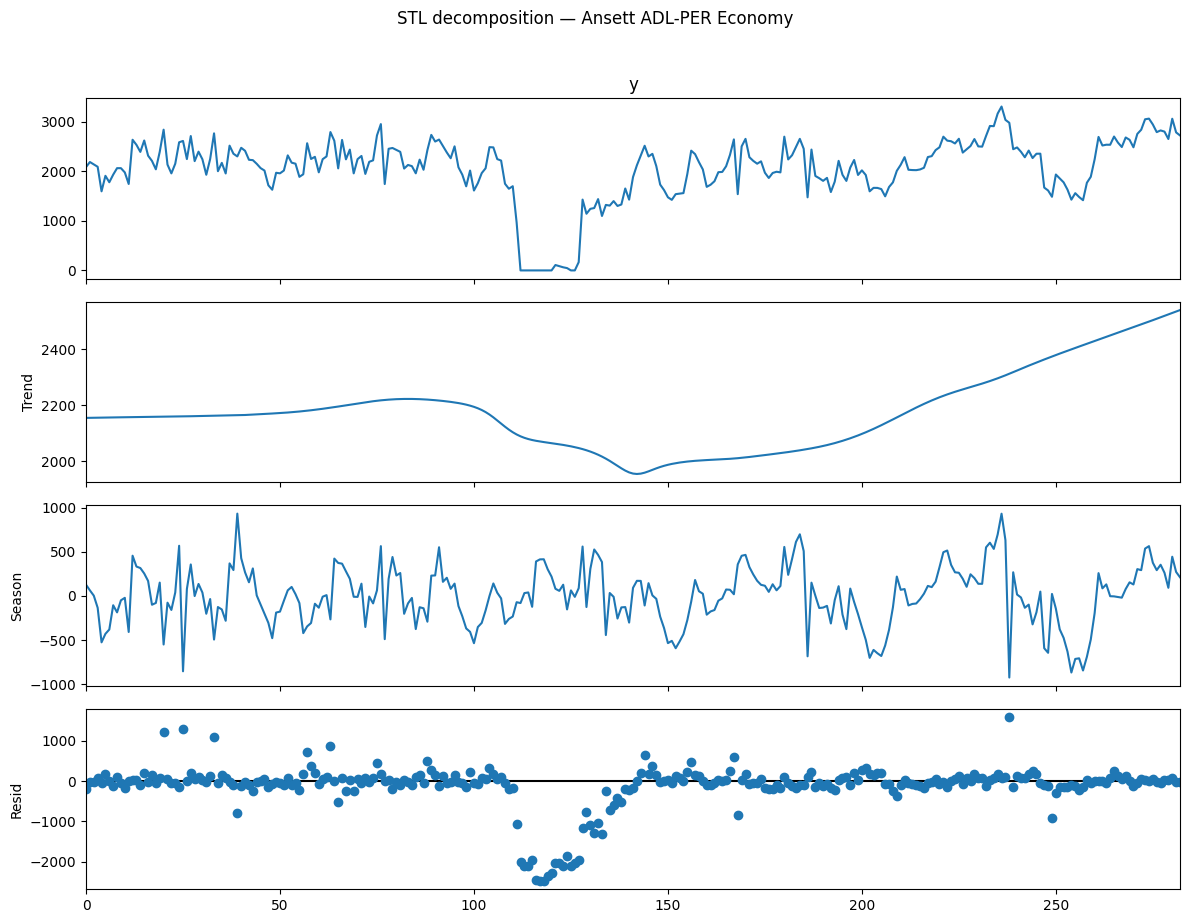

In [28]:
# TODO: STL decomposition (keep the fitted result: Section 3 needs it)

stl = STL(
    work["y"],
    period=mine["season"],
    seasonal=53,
    robust=True
)

stl_fit = stl.fit()

fig = stl_fit.plot()
fig.set_size_inches(12, 9)
fig.suptitle("STL decomposition — Ansett ADL-PER Economy", y=1.02)
plt.tight_layout()
plt.show()

**Your choice of `seasonal` and `robust`, and reading the STL components.**

→ I use period=52, seasonal=53, and robust=True. Since the data are weekly, 52 weeks represent one year. I use 53 for the seasonal smoothing window because it is close to one year and must be an odd number. I use robust=True because of the large drop to zero in 1989. The trend stays around 2200 passengers until 1988, then decreases in 1989–1990 and starts increasing again, reaching about 2600 by the end of 1992. The seasonal component shows a repeating yearly pattern, but it changes over time. Most residuals are close to zero, except for the large negative values during the 1989 disruption. Overall, STL handles the unusual 1989 event better than the classical decomposition.

### 2.3 Classical versus STL

*1 point.* Where do the two disagree — the trend at the edges, the seasonal component over
time, the remainder? Which do you trust more on this series, and what in the plots makes you
say so? A plot that puts the two side by side is the easiest way to show it.

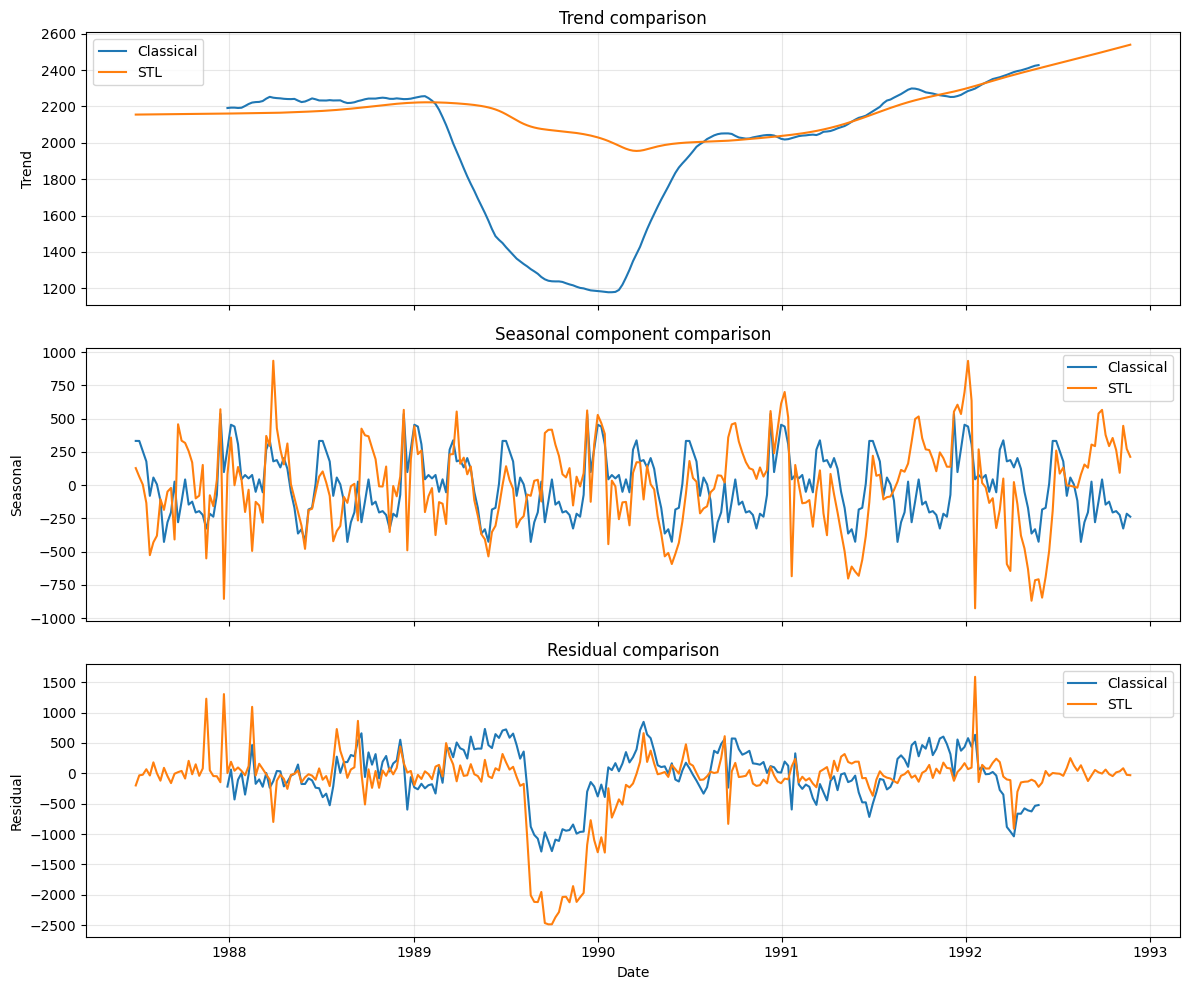

In [29]:
# TODO: compare the two decompositions

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(work["ds"], classical.trend, label="Classical")
axes[0].plot(work["ds"], stl_fit.trend, label="STL")
axes[0].set_title("Trend comparison")
axes[0].set_ylabel("Trend")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(work["ds"], classical.seasonal, label="Classical")
axes[1].plot(work["ds"], stl_fit.seasonal, label="STL")
axes[1].set_title("Seasonal component comparison")
axes[1].set_ylabel("Seasonal")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(work["ds"], classical.resid, label="Classical")
axes[2].plot(work["ds"], stl_fit.resid, label="STL")
axes[2].set_title("Residual comparison")
axes[2].set_ylabel("Residual")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Where they disagree, and which you trust.**

→ The main difference between the two methods is the trend around the 1989 disruption. Classical decomposition shows a much bigger drop, while STL shows a smoother decline and recovery. The seasonal components are also different. Classical has a more stable seasonal pattern, while STL allows it to change over time. Both methods show large negative residuals in 1989, but most STL residuals are close to zero outside this period. I trust STL more because it shows a smoother and more realistic trend and treats the 1989 drop as an unusual event rather than a long-term change.

### 2.4 Seasonally adjusted series

*1 point.* Remove the STL seasonal component and plot the result. Say what it is useful for —
and what it hides.

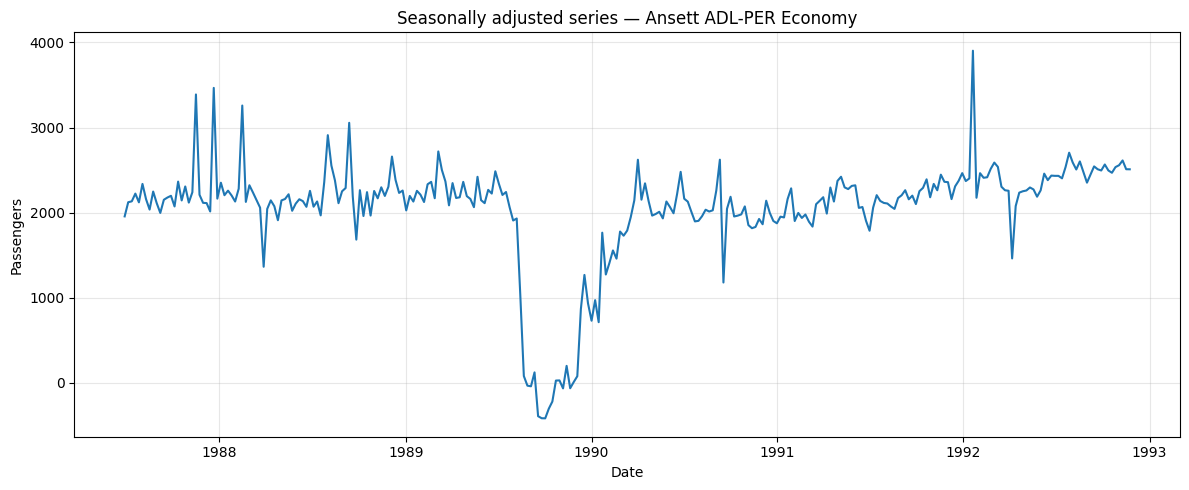

In [30]:
# TODO: seasonally adjusted series

seasonally_adjusted = work["y"] - stl_fit.seasonal

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    work["ds"],
    seasonally_adjusted
)

ax.set_title("Seasonally adjusted series — Ansett ADL-PER Economy")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What it is for, and what it hides.**

→ The seasonally adjusted series removes the regular yearly seasonal pattern, making the underlying movement easier to see. The large drop in 1989 is still visible, which shows that this was an unusual event rather than a normal seasonal change. After the recovery in 1990, the passenger level becomes more stable and then increases during 1991–1992, reaching around 2500–2600 passengers. This adjusted series is useful for looking at the underlying trend without the regular seasonal fluctuations. However, it hides the seasonal pattern, so we can no longer clearly see which periods of the year usually have more or fewer passengers.

## 3. Implementation

*2 points.*

### 3.1 Strength of trend and seasonality

*1 point.*

$$
F_T = \max\left(0,\; 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(T_t + R_t)}\right)
\qquad
F_S = \max\left(0,\; 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}\right)
$$

📖 [FPP 4.3 — where $F_T$ and $F_S$ come from](https://otexts.com/fpp3/stlfeatures.html)

Both come out of a **fitted** STL object: `fit.trend`, `fit.seasonal`, `fit.resid`. A value
outside $[0, 1]$ almost always means the STL object was passed instead of the result of
`.fit()`.

In [31]:
def strengths(stl_fit) -> tuple[float, float]:
    """Return (F_T, F_S) from a fitted STL decomposition."""
    # TODO
    trend = np.asarray(stl_fit.trend)
    seasonal = np.asarray(stl_fit.seasonal)
    resid = np.asarray(stl_fit.resid)

    mask = np.isfinite(trend) & np.isfinite(seasonal) & np.isfinite(resid)

    trend = trend[mask]
    seasonal = seasonal[mask]
    resid = resid[mask]

    F_T = max(
        0,
        1 - np.var(resid) / np.var(trend + resid)
    )

    F_S = max(
        0,
        1 - np.var(resid) / np.var(seasonal + resid)
    )

    return float(F_T), float(F_S)


F_T, F_S = strengths(stl_fit)   # TODO: pass your fitted STL
print(f"F_T = {F_T:.2f}   F_S = {F_S:.2f}")


F_T = 0.14   F_S = 0.05


### 3.2 Explaining last week's winner

*1 point.* In Lab 2 you found which of the four simple methods won on your series. Now explain
**why**, using the decomposition:

- set `LAB2_WINNER` to the method that won in your Lab 2 — it is in your
  `SURNAME_lab02_summary.csv`;
- in three or four sentences, explain that result with $F_T$, $F_S$ and what the components
  show: which component carries the variance, and what the winning method copies forward
  that the other three do not;
- if your Lab 2 prediction was wrong, say what the decomposition shows that the plots did not.

Marked on the **reasoning**: *"snaive won because snaive usually wins"* earns nothing.

**Missed Lab 2?** Run the optional cell below. It recomputes the four methods on the holdout
Lab 2 used.

In [32]:
# OPTIONAL - only if you have no Lab 2 result.
def benchmark_forecasts(y, h, m):
    T = len(y)
    return {
        "mean":   np.repeat(y.mean(), h),
        "naive":  np.repeat(y[-1], h),
        "snaive": np.array([y[-m + (i % m)] for i in range(h)]),
        "drift":  y[-1] + np.arange(1, h + 1) * (y[-1] - y[0]) / (T - 1),
    }


m = mine["season"]
H = m if m >= 12 else 2 * m   # the holdout the Lab 2 template used

# Lab 2 scored the untransformed series: interior gaps filled, a missing tail trimmed.
y_lab2 = s.set_index("ds")["y"].interpolate(limit_area="inside").dropna().to_numpy(float)
train, test = y_lab2[:-H], y_lab2[-H:]
rmse = {k: float(np.sqrt(np.mean((test - v) ** 2)))
        for k, v in benchmark_forecasts(train, H, m).items()}

for name, value in sorted(rmse.items(), key=lambda kv: kv[1]):
    print(f"  {name:7s} RMSE {value:,.2f}")
print("winner:", min(rmse, key=rmse.get))

  snaive  RMSE 468.56
  naive   RMSE 514.84
  drift   RMSE 519.85
  mean    RMSE 696.87
winner: snaive


In [33]:
LAB2_WINNER = "snaive"   # the method that won in your Lab 2: "mean", "naive", "drift" or "snaive"

assert LAB2_WINNER in {"mean", "naive", "drift", "snaive"}, "pick one of the four"

**Your explanation.**

→ The Lab 2 winner was the snaive method, with an RMSE of 468.56, although my original prediction was naive. The STL strength measures show a weak trend and very weak seasonality overall (F_T = 0.14, F_S = 0.05), so neither component explains a large share of the total variance. However, the decomposition still shows recurring within-year structure, and snaive can copy the corresponding observations from the previous year, allowing it to capture local patterns that naive does not. The 1989 disruption and other irregular fluctuations make the overall seasonal strength low, but the snaive method can still benefit from repeated patterns over the 52-week cycle.

## 4. Code quality and reproducibility

*1 point.* Before you export:

- Restart the kernel and run everything top to bottom. It must finish without errors.
- Delete dead cells and leftover experiments.
- Check that every number in your text comes from a cell, not from your memory of an
  earlier run.

## 5. Submit

Run the cell below, then export and upload **three files** to the Week 3 activity on
Moodle before the end of the session:

- `SURNAME_lab03.pdf` — `File → Print → Save as PDF`
- `SURNAME_lab03.ipynb` — `File → Download → Download .ipynb`
- `SURNAME_lab03_summary.csv` — written by the cell below

In [34]:
summary = pd.DataFrame([{
    "student_id": MY_ID,
    "series": mine["label"],
    "F_T": round(float(F_T), 2),
    "F_S": round(float(F_S), 2),
    "lab2_winner": LAB2_WINNER,
}])

name = f"{SURNAME.strip().upper()}_lab03_summary.csv"
summary.to_csv(name, index=False)
print(summary.to_string(index=False))

try:
    from google.colab import files
    files.download(name)
except ImportError:
    print(f"\nNot in Colab — {name} is saved next to this notebook.")

        student_id                                    series  F_T  F_S lab2_winner
mbondar@kse.org.ua Ansett passengers: ADL-PER, Economy class 0.14 0.05      snaive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>